In [1]:
# Movement 
from src.planning.move.network import load_network, enrich_network
from src.planning.move.matrix import build_cost_matrix_for_vehicle

# Scenario
from src.planning.scenario import unit, job, prepare_scenario

# Assignment
from src.planning.assign.Solver import Solver
from src.planning.assign.constraints import add_capacity, add_range_limit, add_optional_jobs
from src.planning.assign.plot import plot_routes_folium, plot_routes_kepler
from src.planning.assign.analysis import print_analysis

### Movement

In [ ]:
# Load road network
G = load_network()

# Enrich network
G = enrich_network(G)

NameError: name 'ox' is not defined

### Scenario

In [3]:
units = [
    # Ground units along a front line (west → east)
    unit("jeep_alpha",   "jeep", lat=54.2400, lon=23.2500, range_left=80000, payload_left=3),
    unit("jeep_bravo",   "jeep", lat=54.2550, lon=23.3200, range_left=80000, payload_left=3),
    unit("jeep_charlie", "jeep", lat=54.2700, lon=23.3900, range_left=80000, payload_left=2),

    # Drones in rear staging area (south-west)
    unit("drone_1", "drone", lat=54.0800, lon=23.1000, range_left=280000, payload_left=2),
    unit("drone_2", "drone", lat=54.0900, lon=23.0500, range_left=260000, payload_left=2),
]

jobs = [
    # Close targets (just ahead of frontline)
    job("target1", lat=54.2850, lon=23.2800, demand=2, priority=6),
    job("target2", lat=54.2950, lon=23.3400, demand=2, priority=6),
    job("target3", lat=54.3050, lon=23.4000, demand=1, priority=8),

    # Mid-range targets (contested zone)
    job("target4", lat=54.3400, lon=23.5000, demand=1, priority=9),
    job("target5", lat=54.3600, lon=23.5800, demand=1, priority=9),

    # Deep targets (enemy rear)
    job("target6", lat=54.4200, lon=23.7500, demand=1, priority=10),
    job("target7", lat=54.4500, lon=23.8500, demand=1, priority=10),

    # Far edge (low priority)
    job("target8", lat=54.5000, lon=24.0000, demand=1, priority=3),
]

locations, vehicles, solver_units = prepare_scenario(units, jobs, G)

### Solve


In [4]:
# Compute cost matrices
cache = {}

for v in vehicles:
    key = v.profile.name  # "jeep", "drone"

    if key not in cache:
        cache[key] = build_cost_matrix_for_vehicle(G, locations, v)

cost_matrices = cache

# Initialize solver
solver = Solver(locations, solver_units, cost_matrices).build()

# add contraints
add_capacity(solver)
add_range_limit(solver)
add_optional_jobs(solver)

# Solve 
solution = solver.solve()

### Results

In [5]:
# Print results 
print_analysis(solver)

──────────────────────────────────────────────────── Solution ─────────────────────────────────────────────────────

                                        Routes                                         
┏━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━┓
┃ Vehicle      ┃ Type  ┃ Route                                                 ┃ Cost ┃
┡━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━┩
│ jeep_alpha   │ jeep  │ jeep_alpha → target1 → jeep_alpha                     │    0 │
│ jeep_bravo   │ jeep  │ jeep_bravo → target6 → target4 → target3 → jeep_bravo │    0 │
│ jeep_charlie │ jeep  │ jeep_charlie → target2 → jeep_charlie                 │    0 │
│ drone_1      │ drone │ drone_1 → target5 → drone_1                           │    0 │
│ drone_2      │ drone │ drone_2 → target7 → target8 → drone_2                 │    0 │
└──────────────┴───────┴───────────────────────────────────────────────────────┴──────┘

                 Vehicle Usage                 
┏━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Vehicle      ┃ Type  ┃ Range Used ┃ Payload ┃
┡━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━┩
│ jeep_alpha   │ jeep  │ 0.0%       │ 2 / 3   │
│ jeep_bravo   │ jeep  │ 0.0%       │ 3 / 3   │
│ jeep_charlie │ jeep  │ 0.0%       │ 2 / 2   │
│ drone_1      │ drone │ 0.0%       │ 1 / 2   │
│ drone_2      │ drone │ 0.0%       │ 2 / 2   │
└──────────────┴───────┴────────────┴─────────┘

All jobs served

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────


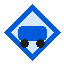
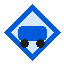
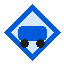
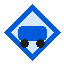
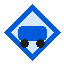
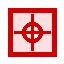
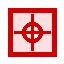
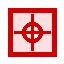
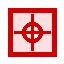
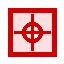
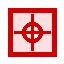
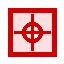
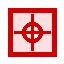

In [6]:
# Plot results 
m = plot_routes_folium(G, locations, solution)
m

In [7]:
m = plot_routes_kepler(G, locations, solution)
m

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


c:\Users\marij\Documents\KIXS\Routing\venv\Lib\site-packages\keplergl\keplergl.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string
c:\Users\marij\Documents\KIXS\Routing\venv\Lib\site-packages\jupyter_client\session.py:727: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)
c:\Users\marij\Documents\KIXS\Routing\venv\Lib\site-packages\jupyter_client\session.py:727: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compl

KeplerGl(data={'locations': {'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'columns': ['id', 'type', 'l…